Silhouette por K: {3: 0.398, 4: 0.421, 5: 0.402, 6: 0.409, 7: 0.411}


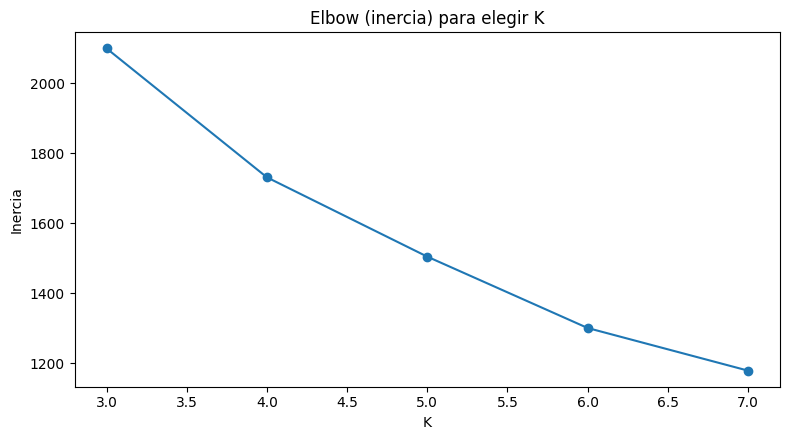

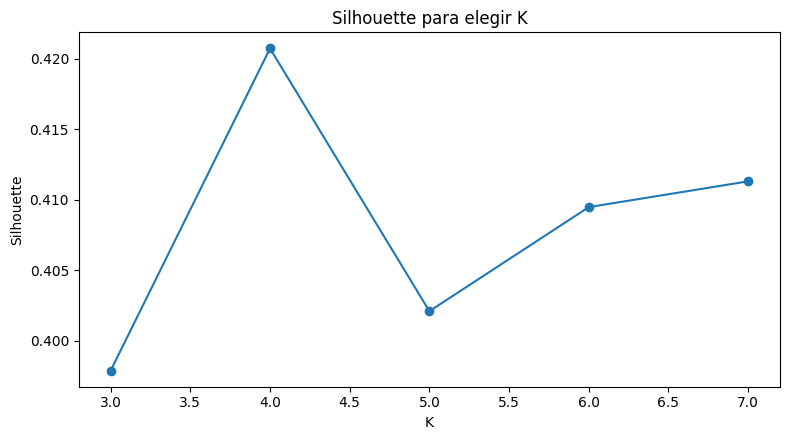

Best K (silhouette): 4

=== Perfil de clusters ===
 cluster  n_skus  ingreso_total  ingreso_prom  unidades_total  precio_prom  active_ratio_prom  cv_prom  mean_week_qty_prom  ingreso_share_%
       1     108       97136950 899416.203704           17491  5766.381667           0.535362 0.608641            3.043922            68.09
       3     296       31666750 106982.263514            5099  6353.564439           0.117375 0.459072            1.549756            22.20
       0      57        7556260 132565.964912             232 34415.067301           0.030744 0.080791            1.483723             5.30
       2     378        6302110  16672.248677             956  6948.506748           0.022953 0.000000            1.113757             4.42

=== Top 10 productos por cluster (por ingreso) ===
 cluster                                                               producto categoria_principal  ingreso_total  unidades_total  active_ratio   cv_qty
       0                               TORT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# CONFIG
# =========================
FILE = Path(r"C:\Users\carlosp\Desktop\Ventas 2026.xlsx")  # poné el Excel en la misma carpeta
YEARS = [2024, 2025]            # más historia = clusters más estables
K_MIN, K_MAX = 3, 7             # rango razonable para empezar
RANDOM_STATE = 42

# =========================
# 1) Load + clean
# =========================
df = pd.read_excel(FILE)

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.dropna(subset=["fecha"]).copy()
df = df[df["fecha"].dt.year.isin(YEARS)].copy()

df["producto"] = df["producto"].astype(str).str.strip()
df["Categoría"] = (df["Categoría"].astype(str)
                   .str.replace("\u00A0", " ", regex=False)
                   .str.strip()
                   .str.title())

df["cantidad"] = pd.to_numeric(df["cantidad"], errors="coerce").fillna(0)
df["precio_diario"] = pd.to_numeric(df["precio_diario"], errors="coerce").fillna(0)

df["ingreso"] = df["cantidad"] * df["precio_diario"]
df["week_start"] = df["fecha"] - pd.to_timedelta(df["fecha"].dt.weekday, unit="D")

# Total de semanas en el rango (para ratio de actividad)
all_weeks = pd.date_range(df["week_start"].min(), df["week_start"].max(), freq="W-MON")
n_weeks_total = len(all_weeks)

# =========================
# 2) Features por producto (mix)
# =========================
# Totales
prod = (df.groupby("producto", as_index=False)
          .agg(
              ingreso_total=("ingreso", "sum"),
              unidades_total=("cantidad", "sum"),
              categoria_principal=("Categoría", lambda s: s.value_counts().index[0]),
          ))

# Semanal por producto
wk = (df.groupby(["producto", "week_start"], as_index=False)
        .agg(qty=("cantidad", "sum"),
             ing=("ingreso", "sum")))

wk_stats = (wk.groupby("producto", as_index=False)
              .agg(
                  mean_week_qty=("qty", "mean"),
                  std_week_qty=("qty", "std"),
                  mean_week_ing=("ing", "mean"),
                  weeks_active=("week_start", "nunique")
              ))

wk_stats["std_week_qty"] = wk_stats["std_week_qty"].fillna(0)
wk_stats["active_ratio"] = wk_stats["weeks_active"] / n_weeks_total

# Variabilidad (CV)
wk_stats["cv_qty"] = np.where(wk_stats["mean_week_qty"] > 0,
                              wk_stats["std_week_qty"] / wk_stats["mean_week_qty"],
                              np.inf)

# Unir
feat = prod.merge(wk_stats, on="producto", how="left")

# Precio promedio (proxy)
feat["precio_promedio"] = np.where(feat["unidades_total"] > 0,
                                   feat["ingreso_total"] / feat["unidades_total"],
                                   0)

# Limpieza de infinitos / nulos
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.dropna(subset=["cv_qty", "mean_week_qty", "active_ratio"]).copy()

# =========================
# 3) Matriz de features (con logs para que no domine la cola larga)
# =========================
X = pd.DataFrame({
    "log_ingreso_total": np.log1p(feat["ingreso_total"]),
    "log_unidades_total": np.log1p(feat["unidades_total"]),
    "log_precio_promedio": np.log1p(feat["precio_promedio"]),
    "active_ratio": feat["active_ratio"],           # 0..1
    "log_mean_week_qty": np.log1p(feat["mean_week_qty"]),
    "log_cv_qty": np.log1p(feat["cv_qty"]),         # variabilidad
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4) Elegir K (silhouette + elbow)
# =========================
ks = list(range(K_MIN, K_MAX + 1))
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

print("Silhouette por K:", dict(zip(ks, [round(s, 3) for s in sils])))

plt.figure(figsize=(8,4.5))
plt.plot(ks, inertias, marker="o")
plt.title("Elbow (inercia) para elegir K")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
plt.plot(ks, sils, marker="o")
plt.title("Silhouette para elegir K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

# Elegimos K por el mejor silhouette (simple)
best_k = ks[int(np.argmax(sils))]
print("Best K (silhouette):", best_k)

# =========================
# 5) Entrenar modelo final
# =========================
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
feat["cluster"] = kmeans.fit_predict(X_scaled)

# =========================
# 6) Perfil de clusters (tabla para negocio)
# =========================
profile = (feat.groupby("cluster", as_index=False)
             .agg(
                 n_skus=("producto", "count"),
                 ingreso_total=("ingreso_total", "sum"),
                 ingreso_prom=("ingreso_total", "mean"),
                 unidades_total=("unidades_total", "sum"),
                 precio_prom=("precio_promedio", "mean"),
                 active_ratio_prom=("active_ratio", "mean"),
                 cv_prom=("cv_qty", "mean"),
                 mean_week_qty_prom=("mean_week_qty", "mean"),
             )
          )

profile["ingreso_share_%"] = (profile["ingreso_total"] / profile["ingreso_total"].sum() * 100).round(2)
profile = profile.sort_values("ingreso_total", ascending=False)

print("\n=== Perfil de clusters ===")
print(profile.to_string(index=False))

# Top 10 productos por cluster (por ingreso)
top_per_cluster = (feat.sort_values(["cluster", "ingreso_total"], ascending=[True, False])
                     .groupby("cluster")
                     .head(10)[["cluster","producto","categoria_principal","ingreso_total","unidades_total","active_ratio","cv_qty"]])

print("\n=== Top 10 productos por cluster (por ingreso) ===")
print(top_per_cluster.to_string(index=False))

# Export opcional
out_dir = Path("outputs_clustering")
out_dir.mkdir(exist_ok=True)
profile.to_csv(out_dir / "cluster_profile.csv", index=False)
feat.to_csv(out_dir / "productos_con_cluster.csv", index=False)
top_per_cluster.to_csv(out_dir / "top10_por_cluster.csv", index=False)
print("\nArchivos guardados en:", out_dir.resolve())